In [5]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [7]:
X_train.shape

(60000, 28, 28)

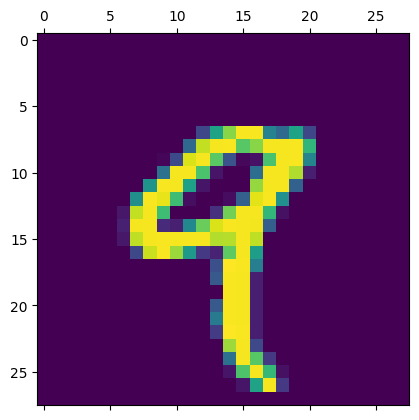

In [8]:
plt.matshow(X_train[4])

In [9]:
X_train = X_train/255

In [10]:
X_test = X_test/255

In [11]:
X_train_flattened = X_train.reshape(len(X_train), 784)

In [12]:
X_train_flattened.shape

(60000, 784)

In [13]:
X_test_flattened = X_test.reshape(len(X_test), 784)

In [14]:
X_test_flattened.shape

(10000, 784)

In [15]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(50, activation = "relu"),
    keras.layers.Dense(10, activation = "sigmoid")
])

model.compile(optimizer = "adam", loss= "sparse_categorical_crossentropy", metrics = ["accuracy"])
model.fit(X_train, y_train, epochs=5)


/Users/apple/Desktop/Data science/venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9093 - loss: 0.3233
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9542 - loss: 0.1599
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9664 - loss: 0.1171
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9724 - loss: 0.0941
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9765 - loss: 0.0790


In [16]:
model.evaluate(X_test_flattened, y_test)

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 784), dtype=float32). Expected shape (None, 28, 28), but input has incompatible shape (None, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 784), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step


array([3.0487741e-03, 6.1059727e-06, 1.0707224e-01, 8.8269806e-01,
       6.8230911e-06, 2.2854961e-03, 4.3668985e-10, 9.9998277e-01,
       1.7994503e-02, 6.8421161e-01], dtype=float32)

In [ ]:
import numpy as np 

np.argmax(y_predicted[0])

7

In [ ]:
y_predicted_labels = [np.argmax(predicted) for predicted in y_predicted ]

In [ ]:
cm = tf.math.confusion_matrix(labels = y_test, predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 968,    0,    0,    1,    1,    0,    4,    2,    3,    1],
       [   0, 1118,    3,    1,    0,    1,    4,    1,    7,    0],
       [   7,    1,  996,    7,    2,    0,    3,    6,    8,    2],
       [   0,    0,    2,  990,    0,    4,    0,    6,    3,    5],
       [   1,    0,    0,    1,  945,    0,    7,    8,    1,   19],
       [   2,    0,    0,   13,    2,  858,    6,    2,    8,    1],
       [   4,    3,    3,    1,    3,    4,  935,    0,    5,    0],
       [   0,    2,    8,    6,    1,    0,    0,  998,    2,   11],
       [   4,    0,    3,    5,    3,    3,    2,    4,  945,    5],
       [   3,    2,    0,    7,    4,    4,    0,    5,    5,  979]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Predicted')

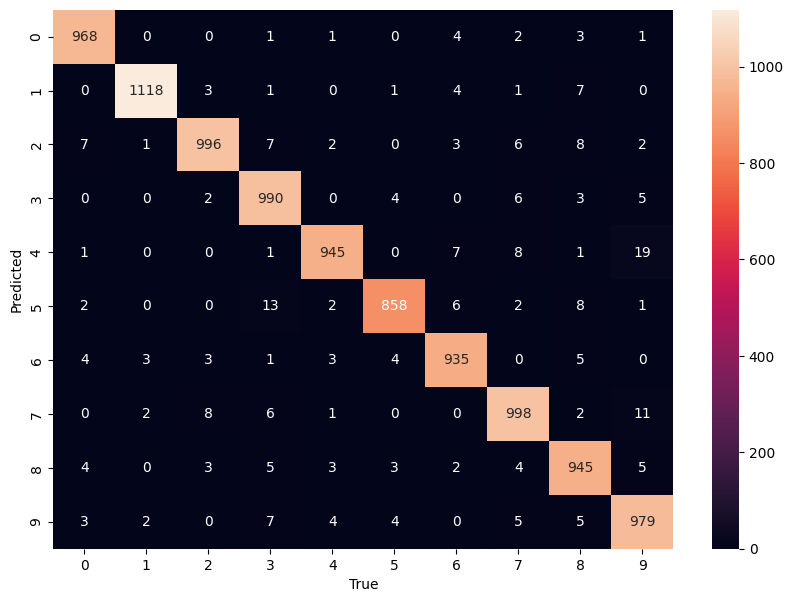

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("True")
plt.ylabel("Predicted")


In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),
    keras.layers.Dense(50, activation = "relu"),
    keras.layers.Dense(10, activation = "sigmoid")
])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)
model.compile(optimizer = "SGD", loss= "sparse_categorical_crossentropy", metrics = ["accuracy"])
model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8203 - loss: 0.6987
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9027 - loss: 0.3493
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9149 - loss: 0.3020
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9227 - loss: 0.2750
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9281 - loss: 0.2545


In [17]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]